In [ ]:
import numpy as np
import pandas as pd

#%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set_style("darkgrid")

%config InlineBackened.format_figure = "svg"

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train , y_train) , (X_test , y_test) = mnist.load_data()

In [ ]:
plt.imshow(X_train[0], cmap='viridis')
plt.show()

In [ ]:
int(X_train[0].max() - X_train[0].min())

In [ ]:
sclaed_X_train = X_train / 255
scaled_X_test = X_test / 255

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten , Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
28*28

In [ ]:
784/2

In [ ]:
encoder = Sequential()
encoder.add(Flatten(input_shape = [28,28]))
encoder.add(Dense(units=400, activation='relu'))
encoder.add(Dense(units=200, activation='relu'))
encoder.add(Dense(units=100, activation='relu'))
encoder.add(Dense(units=50, activation='relu'))
encoder.add(Dense(units=25, activation='relu'))

In [ ]:
25/784 * 100

In [ ]:
decoder = Sequential()
decoder.add(Dense(units = 50 ,  input_shape = [25] , activation = 'relu'))
decoder.add(Dense(units = 100 , activation = 'relu'))
decoder.add(Dense(units = 200 , activation = 'relu'))
decoder.add(Dense(units = 400 , activation = 'relu'))
decoder.add(Dense(units = 784 , activation = 'softmax'))
decoder.add(Reshape([28,28]))

In [ ]:
autoencoder = Sequential([encoder , decoder])
autoencoder.compile(loss = BinaryCrossentropy , optimizer=SGD(learning_rate=1.5) , metrics=['accuracy'])

In [ ]:
model = autoencoder.fit(sclaed_X_train ,sclaed_X_train ,epochs=5, validation_data=[scaled_X_test,scaled_X_test])
model

In [ ]:
metrics = pd.DataFrame(model.history)
metrics.plot()
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [ ]:
passed_images = autoencoder.predict(scaled_X_test[:9+1])

In [ ]:
n = 7

print("Original Image")
plt.imshow(X_test[n])
plt.show()
print('Attempted Reconstructed (after autoencoder)')
plt.imshow(passed_images[n])
plt.show()

## Noise Removal

In [ ]:
from tensorflow.keras.layers import GaussianNoise

In [ ]:
sample = GaussianNoise(.9)

In [ ]:
noisy_images = sample(scaled_X_test[:10], training = True)

In [ ]:
n = 7

print("Original Image")
plt.imshow(X_test[n])
plt.show()
print('Gaussian Noise added to the image')
plt.imshow(noisy_images[n])
plt.show()

### Build our model to filter out the added noise:

In [67]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten , Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy

In [69]:
std_gaussian_noise = 0.75

In [70]:
tf.random.set_seed(seed = 101)
np.random.seed(seed = 101)

encoder = Sequential()
encoder.add(Flatten(input_shape = [28,28]))
encoder.add(GaussianNoise(std_gaussian_noise))


encoder.add(Dense(units=400 , activation='relu'))
encoder.add(Dense(units=200 , activation='relu'))
encoder.add(Dense(units=100 , activation='relu'))
encoder.add(Dense(units=50 , activation='relu'))
encoder.add(Dense(units=25 , activation='relu'))


decoder = Sequential()
decoder.add(Dense(units= 50, input_shape = [25] , activation='relu'))
decoder.add(Dense(units=100 , activation='relu'))
decoder.add(Dense(units=200 , activation='relu'))
decoder.add(Dense(units=400 , activation='relu'))
decoder.add(Dense(units=28*28 , activation='sigmoid'))
decoder.add(Reshape([28,28]))


noise_remover = Sequential([encoder , decoder])
noise_remover.compile(loss = BinaryCrossentropy , 
                    optimizer=SGD(learning_rate=1.5), 
                    metrics = ['accuracy'])

c:\Users\ahmad\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\ahmad\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
noise_remover.fit(sclaed_X_train , 
                  sclaed_X_train , 
                  epochs=8 , 
                  validation_data=(scaled_X_test , scaled_X_test))

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.0831 - loss: 0.2518 - val_accuracy: 0.1159 - val_loss: 0.2468
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1307 - loss: 0.2088 - val_accuracy: 0.1641 - val_loss: 0.1965
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1675 - loss: 0.1798 - val_accuracy: 0.1964 - val_loss: 0.1737
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1815 - loss: 0.1684 - val_accuracy: 0.2056 - val_loss: 0.1718
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1902 - loss: 0.1619 - val_accuracy: 0.2180 - val_loss: 0.1568
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1962 - loss: 0.1570 - val_accuracy: 0.2201 - val_loss: 0.1551
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.2001 - loss: 0.1535 - val_accuracy: 0.2323 - val_loss: 0.1484
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2048 - loss: 0.1504 - 

In [72]:
noise_remover.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 25)             │       420,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 28, 28)         │       421,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,011 (3.21 MB)

 Trainable params: 842,009 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

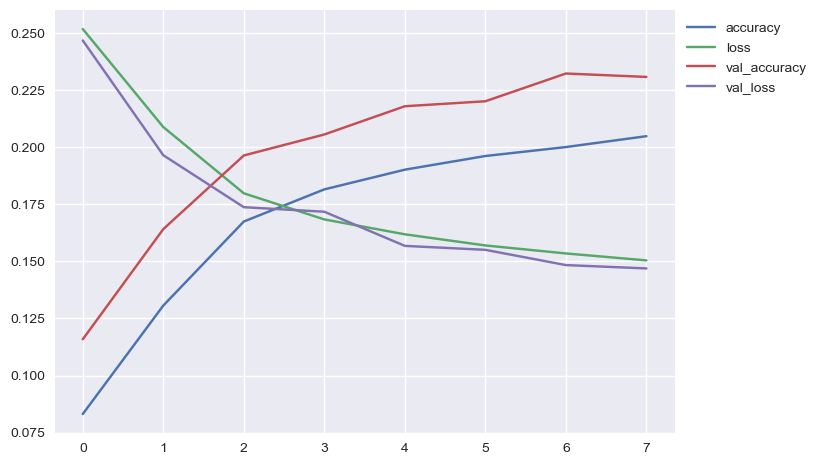

In [73]:
pd.DataFrame(noise_remover.history.history).plot()
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [74]:
sample_number = 10

In [75]:
sample_of_noisy_images = sample(scaled_X_test[:sample_number], training=True)
denoised_images_from_sample = noise_remover(sample_of_noisy_images)
denoised_images_from_sample = noise_remover(sample_of_noisy_images)

ORIGINAL IMAGES FROM SAMPLE


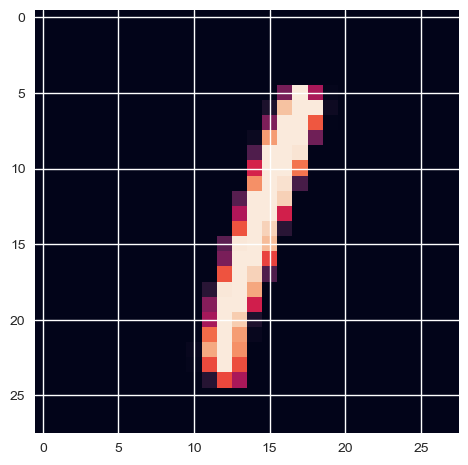

NOISE ADDED IMAGE!


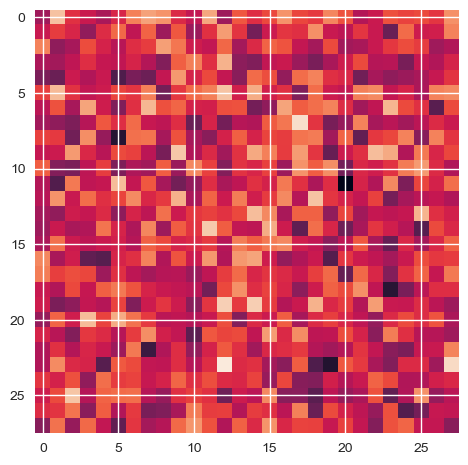

NOISE REMOVED IMAGE !


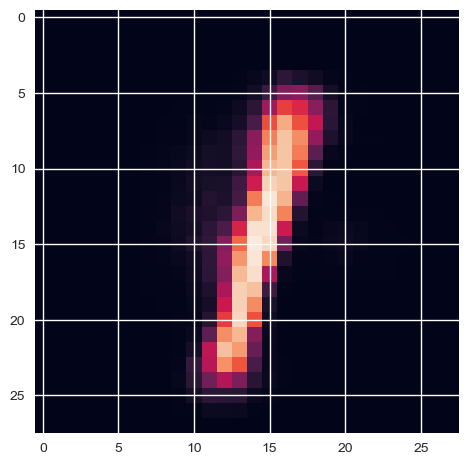

In [76]:
n = 5 # n <= sample_number

print("ORIGINAL IMAGES FROM SAMPLE")
plt.imshow(X_test[n])
plt.show()

print("NOISE ADDED IMAGE!")
plt.imshow(sample_of_noisy_images[n])
plt.show()

print("NOISE REMOVED IMAGE !")
plt.imshow(denoised_images_from_sample[n])
plt.show()